In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb 
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [11]:
df = pd.read_csv('/Users/bigkems/Desktop/Projets Perso/Formation AI-engineer/Projet Fitness_market/data/clean_gym_data.csv')

df["gym_memberships_log"] = np.log1p(df["gym_memberships"])

# definition de la target
y = df["gym_memberships_log"]

# definition des Features
X = df.drop(columns=["gym_memberships",
    "gym_memberships_log",
    "gym_penetration_rate",
    "fitness_participation_rate",
    "total_health_club_revenue_usd"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

# L'encoding 
 
# Identification des colonnes categorielles
categorical_features = ["country", "region"]

# Creer le transformer 
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Entrainemeng du model
xgb_model.fit(X_train_encoded, y_train)

# Prediction du model
y_pred_xgb = xgb_model.predict(X_test_encoded)

In [12]:
importances = xgb_model.feature_importances_

In [13]:
feature_names = preprocessor.get_feature_names_out()

In [14]:
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp = feat_imp.sort_values(by="importance", ascending=False)
feat_imp

,feature,importance
139,remainder__number_of_gyms,0.498369
143,remainder__population_total,0.249186
132,cat__region_Africa,0.104990
142,remainder__gdp_per_capita_usd,0.050701
144,remainder__average_membership_cost_usd,0.049351
...,...,...
109,cat__country_South Korea,0.000000
110,cat__country_Spain,0.000000
112,cat__country_Sudan,0.000000
113,cat__country_Suriname,0.000000


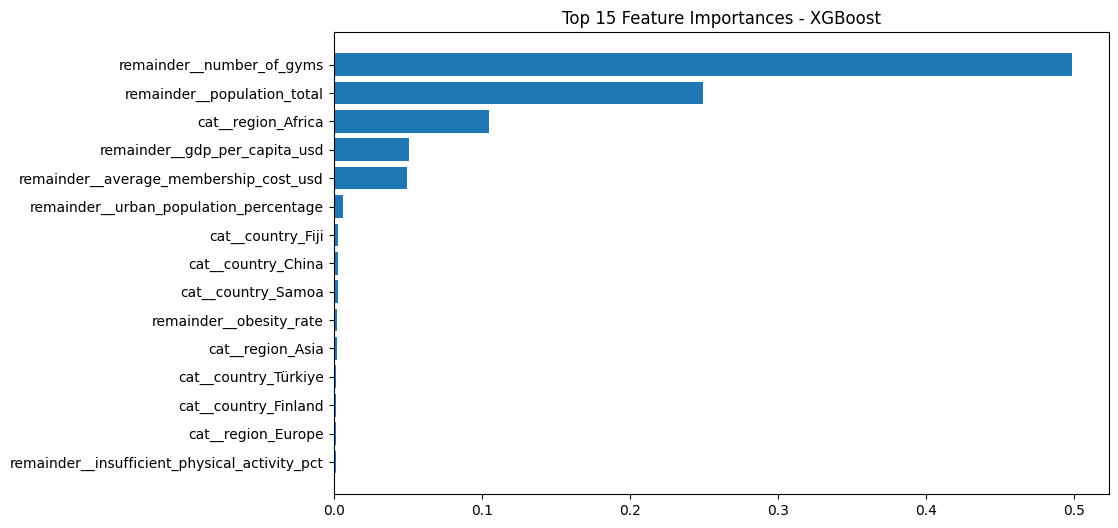

In [15]:
plt.figure(figsize=(10,6))

top_features = feat_imp.head(15)

plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()